# MLP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import sys
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(str(Path('..').resolve()))

from src.utils.paths import PROCESSED_DIR, RESULTS_DIR, setup_plotting, ensure_dirs
from src.data.preprocessing import prepare_data
from src.models.mlp import MLP
from src.training.mlp import train_mlp_with_cv

setup_plotting()
ensure_dirs()

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## Load Datasets

In [2]:
dataset_A = pd.read_csv(PROCESSED_DIR / 'dataset_A_full.csv')
dataset_B = pd.read_csv(PROCESSED_DIR / 'dataset_B_metabolomics.csv')
dataset_C = pd.read_csv(PROCESSED_DIR / 'dataset_C_transcriptomics.csv')

print("Dataset shapes:")
print(f"  A (Full): {dataset_A.shape}")
print(f"  B (Metabolomics): {dataset_B.shape}")
print(f"  C (Transcriptomics): {dataset_C.shape}")

Dataset shapes:
  A (Full): (33, 1176)
  B (Metabolomics): (79, 206)
  C (Transcriptomics): (31, 212)


In [3]:

X_A, y_A, features_A = prepare_data(dataset_A, "Dataset A")
X_B, y_B, features_B = prepare_data(dataset_B, "Dataset B")
X_C, y_C, features_C = prepare_data(dataset_C, "Dataset C")


Dataset A: 33 samples, 1169 features

Dataset B: 79 samples, 199 features

Dataset C: 31 samples, 205 features


## Hyperparameter Search

Systematic search for optimal MLP configuration on each dataset

In [4]:
# from itertools import product
#
# def hyperparameter_search(X, y, param_grid, n_splits=5, random_state=42):
#     """
#     Grid search over hyperparameters with cross-validation.
#     """
#     results = []
#
#     # Generate all combinations
#     keys = list(param_grid.keys())
#     values = list(param_grid.values())
#     combinations = list(product(*values))
#
#     print(f"Testing {len(combinations)} hyperparameter combinations...\n")
#
#     for i, combo in enumerate(combinations, 1):
#         params = dict(zip(keys, combo))
#         print(f"[{i}/{len(combinations)}] Testing: {params}")
#
#         # Train with these params
#         result = train_mlp_with_cv(
#             X, y, None,
#             n_splits=n_splits,
#             hidden_dims=params['hidden_dims'],
#             dropout=params['dropout'],
#             lr=params['lr'],
#             epochs=params['epochs'],
#             random_state=random_state
#         )
#
#         results.append({
#             **params,
#             'mean_r2': result['mean_r2'],
#             'std_r2': result['std_r2'],
#             'mean_rmse': result['mean_rmse'],
#             'mean_mae': result['mean_mae']
#         })
#
#         print()
#
#     # Convert to dataframe and sort by R²
#     results_df = pd.DataFrame(results)
#     results_df = results_df.sort_values('mean_r2', ascending=False)
#
#     return results_df
#
# # Define parameter grid
# param_grid = {
#     'hidden_dims': [
#         [128, 64],
#         [128, 64, 32],
#         [256, 128, 64],
#         [64, 32],
#         [128, 128, 64]
#     ],
#     'dropout': [0.2, 0.3, 0.4, 0.5],
#     'lr': [0.0005, 0.001, 0.002],
#     'epochs': [100, 200, 300, 400]
# }
#
# print("Hyperparameter grid:")
# for k, v in param_grid.items():
#     print(f"  {k}: {len(v)} options")
# print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")

In [5]:
# # Run hyperparameter search on Dataset B
# print("="*60)
# print("HYPERPARAMETER SEARCH: DATASET B")
# print("="*60)
# print()
#
# hyperparam_results = hyperparameter_search(X_B, y_B, param_grid, n_splits=5)
#
# print("\n" + "="*60)
# print("TOP 10 CONFIGURATIONS")
# print("="*60)
# print(hyperparam_results.head(10).to_string(index=False))
#
# # Save results
#
#
# hyperparam_results.to_csv(RESULTS_DIR / 'mlp_hyperparam_search_B.csv', index=False)
# print(f"\nFull results saved to {RESULTS_DIR / 'mlp_hyperparam_search_B.csv'}")

In [6]:
# # Extract best configuration
# best = hyperparam_results.iloc[0]
#
# print("="*60)
# print("BEST CONFIGURATION")
# print("="*60)
# print(f"Hidden dims: {best['hidden_dims']}")
# print(f"Dropout: {best['dropout']}")
# print(f"Learning rate: {best['lr']}")
# print(f"Epochs: {int(best['epochs'])}")
# print()
# print(f"Performance:")
# print(f"  R² = {best['mean_r2']:.3f} ± {best['std_r2']:.3f}")
# print(f"  RMSE = {best['mean_rmse']:.3f}")
# print(f"  MAE = {best['mean_mae']:.3f}")

## Train on All Datasets

In [7]:
# Using best params from step above
print("="*60)
print("DATASET A: Full")
print("="*60)
results_A = train_mlp_with_cv(X_A, y_A, features_A, hidden_dims=[128, 64, 32], dropout=0.3, epochs=100, lr=0.001)

print("\n" + "="*60)
print("DATASET B: Metabolomics")
print("="*60)
results_B = train_mlp_with_cv(X_B, y_B, features_B, hidden_dims=[128, 64, 32], dropout=0.3, epochs=100, lr=0.001)

print("\n" + "="*60)
print("DATASET C: Transcriptomics")
print("="*60)
results_C = train_mlp_with_cv(X_C, y_C, features_C, hidden_dims=[128, 64, 32], dropout=0.3, epochs=100, lr=0.001)

DATASET A: Full
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...


  Fold 1: R²=-0.758, RMSE=3.862, MAE=2.904
  Fold 2: R²=0.077, RMSE=5.234, MAE=4.239


  Fold 3: R²=-3.974, RMSE=9.627, MAE=5.921
  Fold 4: R²=-0.487, RMSE=5.397, MAE=3.876


  Fold 5: R²=-0.710, RMSE=2.422, MAE=1.959

R² = -1.170 ± 1.602

DATASET B: Metabolomics
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...


  Fold 1: R²=-0.604, RMSE=4.941, MAE=3.676
  Fold 2: R²=0.183, RMSE=3.232, MAE=2.952


  Fold 3: R²=0.357, RMSE=3.825, MAE=3.218
  Fold 4: R²=-0.191, RMSE=3.916, MAE=3.225


  Fold 5: R²=0.247, RMSE=3.148, MAE=2.262

R² = -0.002 ± 0.395

DATASET C: Transcriptomics
Using device: cuda
Training 5-fold CV (Imputation & Scaling inside folds)...
  Fold 1: R²=0.555, RMSE=3.190, MAE=2.255


  Fold 2: R²=0.447, RMSE=2.923, MAE=2.041


  Fold 3: R²=0.247, RMSE=3.310, MAE=2.194
  Fold 4: R²=0.604, RMSE=1.338, MAE=1.150


  Fold 5: R²=0.793, RMSE=2.568, MAE=2.057

R² = 0.529 ± 0.201


## Results Summary

In [8]:
summary = pd.DataFrame([
    {'Dataset': 'A (Full)', 'N': len(X_A), 'Features': X_A.shape[1],
     'R²': f"{results_A['mean_r2']:.3f} ± {results_A['std_r2']:.3f}",
     'RMSE': f"{results_A['mean_rmse']:.3f} ± {results_A['std_rmse']:.3f}",
     'MAE': f"{results_A['mean_mae']:.3f} ± {results_A['std_mae']:.3f}"},
    {'Dataset': 'B (Metabolomics)', 'N': len(X_B), 'Features': X_B.shape[1],
     'R²': f"{results_B['mean_r2']:.3f} ± {results_B['std_r2']:.3f}",
     'RMSE': f"{results_B['mean_rmse']:.3f} ± {results_B['std_rmse']:.3f}",
     'MAE': f"{results_B['mean_mae']:.3f} ± {results_B['std_mae']:.3f}"},
    {'Dataset': 'C (Transcriptomics)', 'N': len(X_C), 'Features': X_C.shape[1],
     'R²': f"{results_C['mean_r2']:.3f} ± {results_C['std_r2']:.3f}",
     'RMSE': f"{results_C['mean_rmse']:.3f} ± {results_C['std_rmse']:.3f}",
     'MAE': f"{results_C['mean_mae']:.3f} ± {results_C['std_mae']:.3f}"}
])

print("\nRESULTS SUMMARY:")
print(summary.to_string(index=False))
summary.to_csv(RESULTS_DIR / 'mlp_summary.csv', index=False)


RESULTS SUMMARY:
            Dataset  N  Features             R²          RMSE           MAE
           A (Full) 33      1169 -1.170 ± 1.602 5.308 ± 2.697 3.780 ± 1.490
   B (Metabolomics) 79       199 -0.002 ± 0.395 3.812 ± 0.718 3.067 ± 0.520
C (Transcriptomics) 31       205  0.529 ± 0.201 2.666 ± 0.795 1.939 ± 0.450


## Visualizations

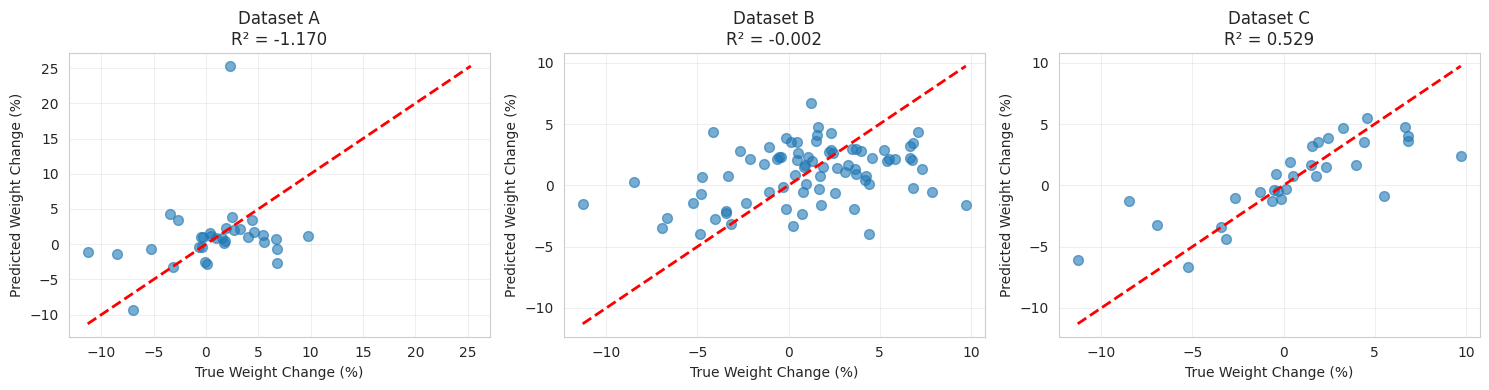

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, results, name in zip(axes, [results_A, results_B, results_C], ['Dataset A', 'Dataset B', 'Dataset C']):
    ax.scatter(results['y_true'], results['y_pred'], alpha=0.6, s=50)
    min_val = min(results['y_true'].min(), results['y_pred'].min())
    max_val = max(results['y_true'].max(), results['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    ax.set_xlabel('True Weight Change (%)')
    ax.set_ylabel('Predicted Weight Change (%)')
    ax.set_title(f'{name}\nR² = {results["mean_r2"]:.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mlp_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Results

In [10]:
mlp_results = {'dataset_A': results_A, 'dataset_B': results_B, 'dataset_C': results_C, 'summary': summary}
with open(RESULTS_DIR / 'mlp_results.pkl', 'wb') as f:
    pickle.dump(mlp_results, f)
print("Results saved to", RESULTS_DIR)

Results saved to /home/bendavison/PycharmProjects/msc_dissertation/results
